# Prediksi Resiko Diabetes dengan K-Nearest Neighbors (KNN)

#### NIM: A11.2023.15194
#### NAMA: RESTU ARDIANSYAH

##### Source Dataset: https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data

# Ringkasan Project

#### Project ini bertujuan untuk mengembangkan model prediksi risiko diabetes menggunakan algoritma K-Nearest Neighbors (KNN). Model ini akan membantu dalam deteksi dini diabetes berdasarkan karakteristik medis pasien seperti kadar glukosa, BMI, usia, dan riwayat keluarga diabetes.

# Permasalahan

#### 1. Masalah Kesehatan: Diabetes merupakan penyakit kronis yang memerlukan di deteksi sejak dini untuk pencegahan komplikasi
#### 2. Keterbatasan Akses: Tidak semua orang memiliki akses mudah ke pemeriksaan medis komprehensif
#### 3. Biaya Diagnosis: Pemeriksaan medis lengkap memerlukan biaya yang tidak sedikit
#### 4. Efisiensi Waktu: Proses diagnosis tradisional memakan waktu yang lama

# Tujuan Yang Akan Dicapai

#### Tujuan utamanya untuk Mengembangkan model prediksi diabetes yang akurat menggunakan KNN

#### Tujuan Spesifik ada beberapa hal diantaranya:
#### 1. Mencapai akurasi model minimal 75%
#### 2. Mengidentifikasi fitur-fitur yang paling berpengaruh terhadap diabetes
#### 3. Membuat model yang dapat digunakan untuk screening awal diabetes
#### 4. Menganalisis performa model dengan berbagai metrik evaluasi

# Tahap Penyelesaian

#### Data Collection -> Data Exploration and Understanding -> Feature Selection (4 features) -> Data Cleaning and Preprocessing -> Feature Scaling -> Data Splitting 80% Train and 20% Test -> KNN Model Traning (K=7 neighbors) -> Model Evaluation and Preformace Analysis -> Result and Visualisasi

##### Project ini tidak menebak outcome yang sudah ada, tapi mempelajari pola hubungan antara karakteristik pasien (glucose, BMI, age, pedigree) dengan risiko diabetes. Ketika ada pasien baru, model dapat memprediksi risikonya berdasarkan pola yang dipelajari dari data historis.

##### Jika ingin membaca dokumentasi lebih lengkap dapat dilihat pada file Dokumentasi Project.pdf di folder ML-A11.2023.15194-UAS

# 1. Import Library

### Import library utama untuk data manipulation dan machine learning

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import library untuk preprocessing dan model

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import joblib

# 2. Eksplorasi Data

### untuk membaca file CSV dataset diabetes

In [78]:
data = pd.read_csv("dataset/diabetes.csv")

### Menampilkan struktur data untuk pemahaman awal

In [79]:
print("Shape data:", data.shape)
print("\nInfo data:")
print(data.info())

Shape data: (768, 9)

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


### Menampilkan tipe data di setiap kolom untuk validasi

In [80]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

# 3. Seleksi Fitur

### Memilih kolom yang paling relevan untuk prediksi diabetes
### Glucose: Kadar gula darah (indikator utama diabetes)
### BMI: Body Mass Index (faktor risiko obesitas)
### Age: Usia (faktor risiko bertambah dengan usia)
### DiabetesPedigreeFunction: Fungsi riwayat keluarga diabetes
### Outcome: Target variable (0=tidak diabetes, 1=diabetes)

In [81]:
kolom_dipilih = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Outcome']
data = data[kolom_dipilih]

### Menampilkan statistik deskriptif untuk understanding distribusi data

In [82]:
data.describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,31.992578,33.240885,0.471876,0.348958
std,31.972618,7.884160,11.760232,0.331329,0.476951
min,0.000000,0.000000,21.000000,0.078000,0.000000
25%,99.000000,27.300000,24.000000,0.243750,0.000000
50%,117.000000,32.000000,29.000000,0.372500,0.000000
75%,140.250000,36.600000,41.000000,0.626250,1.000000
max,199.000000,67.100000,81.000000,2.420000,1.000000


# 4. Data Cleaning dan Preprocessing

### Menangani nilai yang tidak valid (0 pada Glucose dan BMI tidak masuk akal secara medis)
### Mengubah nilai 0 menjadi NaN untuk kolom yang tidak bisa bernilai 0

In [83]:
kolom_tidak_valid = ['Glucose', 'BMI']
for kolom in kolom_tidak_valid:
    data[kolom] = data[kolom].replace(0, np.nan)
    print(f"Jumlah nilai 0 yang diubah ke NaN pada {kolom}: {data[kolom].isna().sum()}")

Jumlah nilai 0 yang diubah ke NaN pada Glucose: 5
Jumlah nilai 0 yang diubah ke NaN pada BMI: 11


### Mengisi nilai NaN dengan median untuk menghindari bias dari outlier
### Median lebih robust terhadap outlier dibandingkan mean

In [84]:
data = data.fillna(data.median(numeric_only=True))

### Verifikasi tidak ada missing values setelah cleaning

In [85]:
print("Jumlah missing values setelah cleaning:")
data.isnull().sum()

Jumlah missing values setelah cleaning:


Glucose                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
dtype: int64

# 5. Pemisahan Fitur dan Target

### Memisahkan features (X) dan target variable (y)
### X berisi semua fitur untuk prediksi

In [86]:
X = data.drop('Outcome', axis=1)

### y berisi target variable (hasil diagnosa diabetes)

In [87]:
y = data['Outcome']

In [88]:
print(f"Shape features (X): {X.shape}")
print(f"Shape target (y): {y.shape}")
print(f"Distribusi target:\n{y.value_counts()}")

Shape features (X): (768, 4)
Shape target (y): (768,)
Distribusi target:
Outcome
0    500
1    268
Name: count, dtype: int64


# 6. Feature Scaling 

### Inisialisasi StandardScaler untuk normalisasi fitur
### KNN sensitif terhadap skala fitur, sehingga scaling diperlukan

In [89]:
scaler = StandardScaler()

### Fit scaler pada data dan transform fitur
### Scaling mengubah distribusi menjadi mean=0 dan std=1

In [90]:
X_scaled = scaler.fit_transform(X)

### Menyimpan scaler untuk prediksi data baru bila nanti dipelukan

In [91]:
joblib.dump(scaler, 'scaler_knn.pkl')

['scaler_knn.pkl']

### Membuat DataFrame dari hasil scaling untuk visualisasi

In [92]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [93]:
print("Data setelah scaling:")
print(X_scaled_df.head())
print("\nStatistik setelah scaling:")
print(X_scaled_df.describe())

Data setelah scaling:
    Glucose       BMI       Age  DiabetesPedigreeFunction
0  0.866045  0.166619  1.425995                  0.468492
1 -1.205066 -0.852200 -0.190672                 -0.365061
2  2.016662 -1.332500 -0.105584                  0.604397
3 -1.073567 -0.633881 -1.041549                 -0.920763
4  0.504422  1.549303 -0.020496                  5.484909

Statistik setelah scaling:
            Glucose           BMI           Age  DiabetesPedigreeFunction
count  7.680000e+02  7.680000e+02  7.680000e+02              7.680000e+02
mean   4.625929e-18  2.613650e-16  1.931325e-16              2.451743e-16
std    1.000652e+00  1.000652e+00  1.000652e+00              1.000652e+00
min   -2.552931e+00 -2.074783e+00 -1.041549e+00             -1.189553e+00
25%   -7.201630e-01 -7.212087e-01 -7.862862e-01             -6.889685e-01
50%   -1.530732e-01 -2.258989e-02 -3.608474e-01             -3.001282e-01
75%    6.112653e-01  6.032562e-01  6.602056e-01              4.662269e-01
max    2.5

# 7. Analisis Korelasi

### Menghitung korelasi antar fitur untuk memahami hubungan
### Korelasi tinggi bisa menunjukkan multikolinearitas

In [94]:
correlation = X.corr()
print("Matriks korelasi antar fitur:")
print(correlation)

Matriks korelasi antar fitur:
                           Glucose       BMI       Age  \
Glucose                   1.000000  0.231049  0.266909   
BMI                       0.231049  1.000000  0.025597   
Age                       0.266909  0.025597  1.000000   
DiabetesPedigreeFunction  0.137327  0.153438  0.033561   

                          DiabetesPedigreeFunction  
Glucose                                   0.137327  
BMI                                       0.153438  
Age                                       0.033561  
DiabetesPedigreeFunction                  1.000000  


### Visualisasi korelasi dengan heatmap

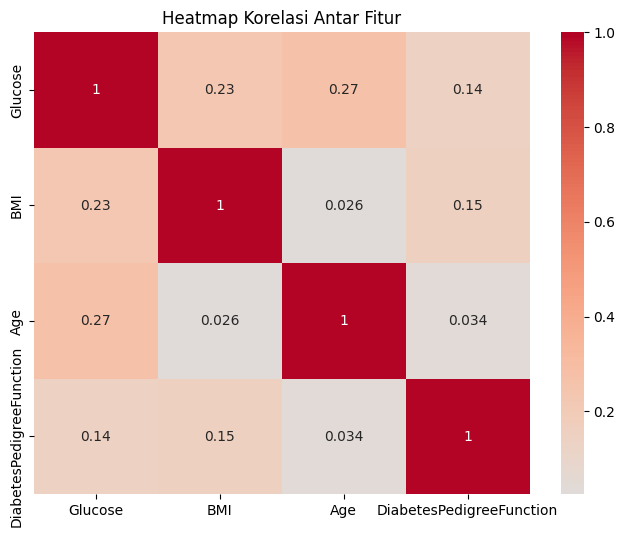

In [95]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# 8. Split Data Training dan Testing

### Membagi data menjadi training set (80%) dan testing set (20%)
### stratify=y memastikan proporsi kelas sama di train dan test
### random_state=42 untuk reproducibility

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
print(f"Data training: {X_train.shape}")
print(f"Data testing: {X_test.shape}")
print(f"Distribusi kelas training:\n{pd.Series(y_train).value_counts()}")
print(f"Distribusi kelas testing:\n{pd.Series(y_test).value_counts()}")

Data training: (614, 4)
Data testing: (154, 4)
Distribusi kelas training:
Outcome
0    400
1    214
Name: count, dtype: int64
Distribusi kelas testing:
Outcome
0    100
1     54
Name: count, dtype: int64


# 9. Training Model KNN

### Inisialisasi model KNN dengan K=7
### K=7 dipilih sebagai nilai ganjil untuk menghindari tie dalam voting

In [98]:
knn_model = KNeighborsClassifier(n_neighbors=7)

### Training model menggunakan data training

In [99]:
knn_model.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Menyimpan model yang sudah ditraining untuk penggunaan future

In [100]:
joblib.dump(knn_model, 'knn_diabetes_model.pkl')

['knn_diabetes_model.pkl']

# 10. Prediksi dan Evaluasi

### Melakukan prediksi pada data test

In [101]:
y_pred = knn_model.predict(X_test)

### Mendapatkan probabilitas prediksi untuk analisis lebih lanjut

In [102]:
y_pred_proba = knn_model.predict_proba(X_test)

### Menghitung berbagai metrik evaluasi

In [103]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

### Menampilkan hasil evaluasi

In [104]:
print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall: {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-Score: {f1:.3f} ({f1*100:.1f}%)")

Accuracy: 0.734 (73.4%)
Precision: 0.644 (64.4%)
Recall: 0.537 (53.7%)
F1-Score: 0.586 (58.6%)


# 11. Classification Report

### Menampilkan classification report untuk detail per kelas

In [105]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.77      0.84      0.80       100
    Diabetes       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



# 12. Confusion Matrix

### Membuat confusion matrix untuk analisis kesalahan prediksi

In [106]:
cm = confusion_matrix(y_test, y_pred)

In [107]:
print("Predicted    No Diabetes | Diabetes")
print(f"No Diabetes      {cm[0,0]:2d}      |    {cm[0,1]:2d}")
print(f"Diabetes         {cm[1,0]:2d}      |    {cm[1,1]:2d}")

Predicted    No Diabetes | Diabetes
No Diabetes      84      |    16
Diabetes         25      |    29


### Visualisasi confusion matrix dengan heatmap

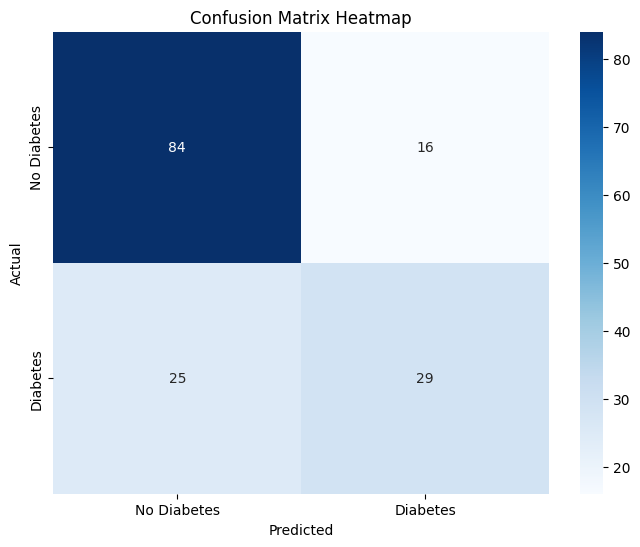

In [108]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 13. Visualisasi Hasil

### Visualisasi distribusi hasil prediksi

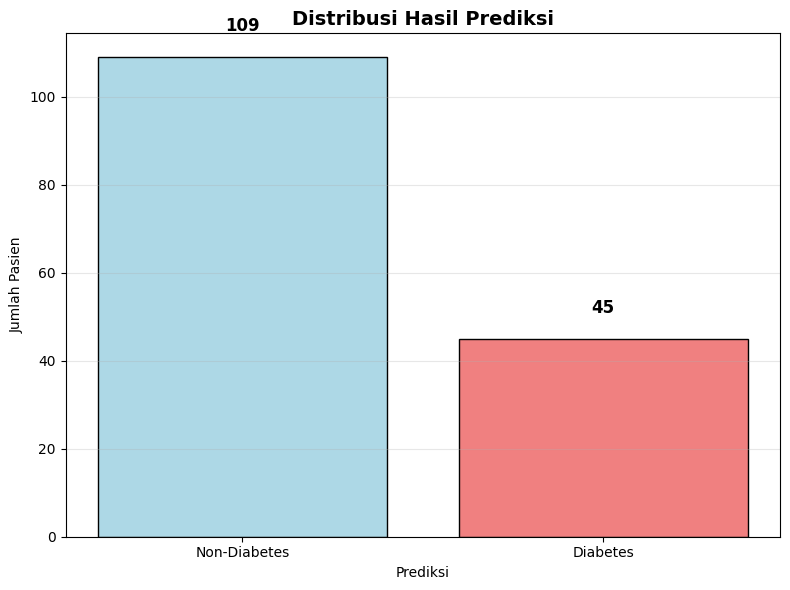

In [109]:
# Visualisasi distribusi hasil prediksi
unique, counts = np.unique(y_pred, return_counts=True)
labels = ['Non-Diabetes', 'Diabetes']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['lightblue', 'lightcoral'], edgecolor='black')

# Menambahkan label angka di atas setiap bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribusi Hasil Prediksi', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Jumlah Pasien')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()